# Visualization for data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# 1. Load data

In [7]:
train_df = pd.read_csv('../hf_dataset_merged/metadata_train.csv')
val_df = pd.read_csv('../hf_dataset_merged/metadata_val.csv')
test_df = pd.read_csv('../hf_dataset_merged/metadata_test.csv')

# Add column to identify dataset split
train_df['dataset'] = 'train'
val_df['dataset'] = 'val' 
test_df['dataset'] = 'test'

# Combine all dataframes
all_data = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Total samples: {len(all_data)}")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
all_data.head()

Total samples: 2180
Training samples: 1744
Validation samples: 218
Test samples: 218


,file_name,label,dataset
0,data/61f8c684-7279806259790925074.mp4,cultural_violation,train
1,data/d18398c5-7564193864886586680.mp4,sexual_harm,train
2,data/ca2860fa-7479882884640214280.mp4,normal_content,train
3,data/c659b933-7320330706964565280.mp4,normal_content,train
4,data/3d10068e-7557307859709463816.mp4,sexual_harm,train


# 2. Basic Analyze

In [9]:
print("\nDataset information")
print(all_data.info())

print("\nNull values")
print(all_data.isnull().sum())


Dataset information
<class 'pandas.DataFrame'>
RangeIndex: 2180 entries, 0 to 2179
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   file_name  2180 non-null   str  
 1   label      2180 non-null   str  
 2   dataset    2180 non-null   str  
dtypes: str(3)
memory usage: 51.2 KB
None

Null values
file_name    0
label        0
dataset      0
dtype: int64


# 3. Multi-Label
One of videos have multi-label, so we need to slit them to analyze

In [14]:
# Extract labels
def extract_labels(label_str):
    return [label.strip() for label in str(label_str).split(',')]

# Create label list
all_labels = []
for label in all_data['label']:
    all_labels.extend(extract_labels(label))

# Count label frequencies
label_counts = Counter(all_labels)
print(f"Total unique labels: {len(label_counts)}")
print("\nLabel frequencies:")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{label:30s}: {count:4d} ({(count/len(all_data))*100:.2f}%)")


Total unique labels: 15

Label frequencies:
normal_content                : 1063 (48.76%)
sexual_harm                   :  278 (12.75%)
toxic_behavior                :  137 (6.28%)
dangerous_acts                :  129 (5.92%)
ai_slop                       :  109 (5.00%)
cultural_violation            :  105 (4.82%)
horror_scary                  :   98 (4.50%)
politically_sensitive         :   96 (4.40%)
scam_fraud                    :   85 (3.90%)
game                          :   79 (3.62%)
educational_history           :   58 (2.66%)
game_risk_impact              :   54 (2.48%)
self_harm_suicide             :   52 (2.39%)
graphic_violence              :   49 (2.25%)
gambling_drugs                :   31 (1.42%)


In [15]:
# Check how many samples have multiple labels
multi_label_samples = all_data[all_data['label'].str.contains(',', na=False)]
print(f"\nSamples with multiple labels: {len(multi_label_samples)} ({(len(multi_label_samples)/len(all_data))*100:.2f}%)")
print("\n Examples of multi-label samples:")
multi_label_samples.head()


Samples with multiple labels: 214 (9.82%)

 Examples of multi-label samples:


,file_name,label,dataset
8,data/f941ff2b-Download_18.mp4,"horror_scary,ai_slop",train
23,data/31e76e51-Download_46.mp4,"sexual_harm,ai_slop",train
40,data/03450de7-7511993798759582983.mp4,"dangerous_acts,cultural_violation",train
47,data/e19838ec-Download_-_2026-01-10T190608.069...,"sexual_harm,cultural_violation",train
54,data/7b9eab24-7528211100265893128.mp4,"toxic_behavior,gambling_drugs",train


# 4. Visualization label frequencies

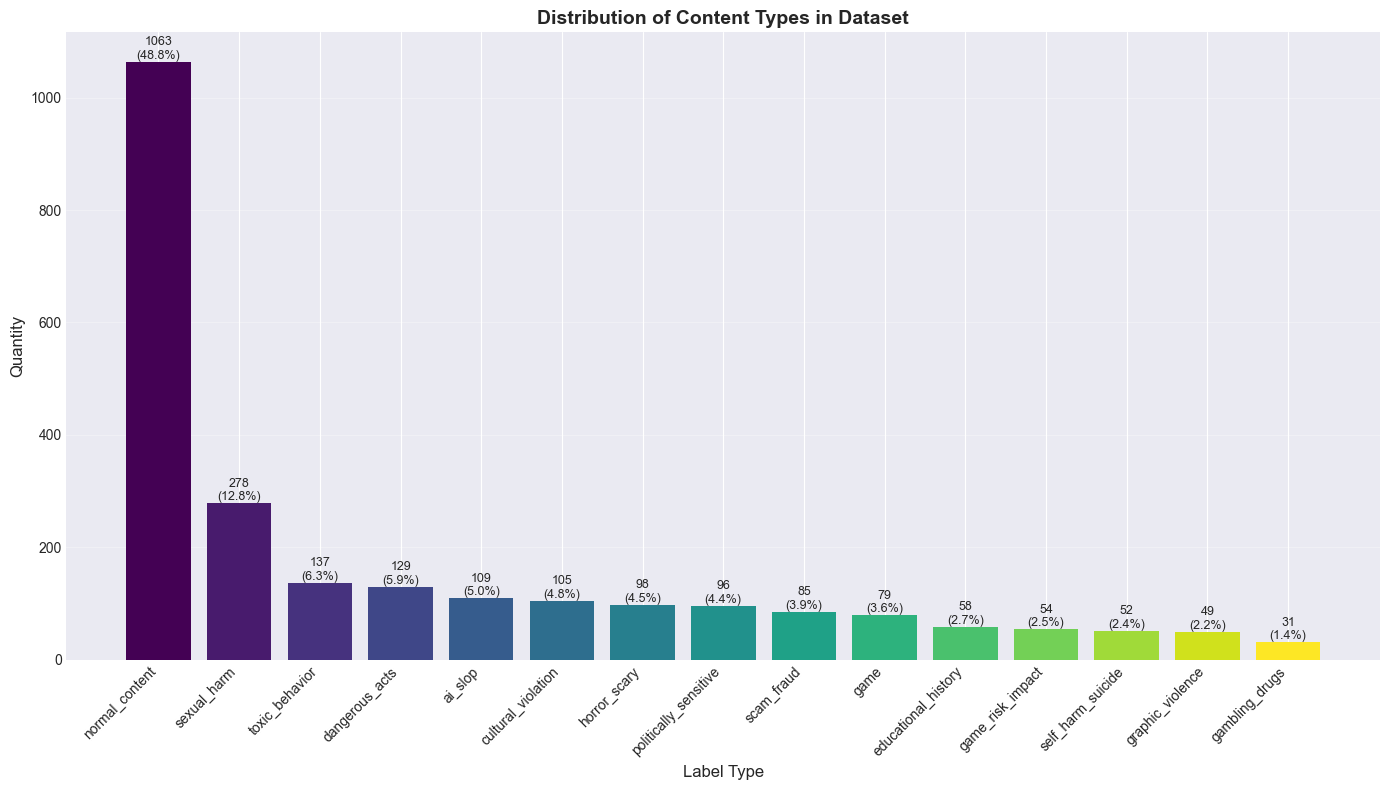

In [16]:
fig, ax = plt.subplots(figsize=(14, 8))
labels_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels = [l[0] for l in labels_sorted]
counts = [l[1] for l in labels_sorted]

bars = ax.bar(range(len(labels)), counts, color=plt.cm.viridis(np.linspace(0, 1, len(labels))))
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Quantity', fontsize=12)
ax.set_xlabel('Label Type', fontsize=12)
ax.set_title('Distribution of Content Types in Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add data labels on each bar
for i, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(all_data)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 5. Analyze dataset (train/val/test)

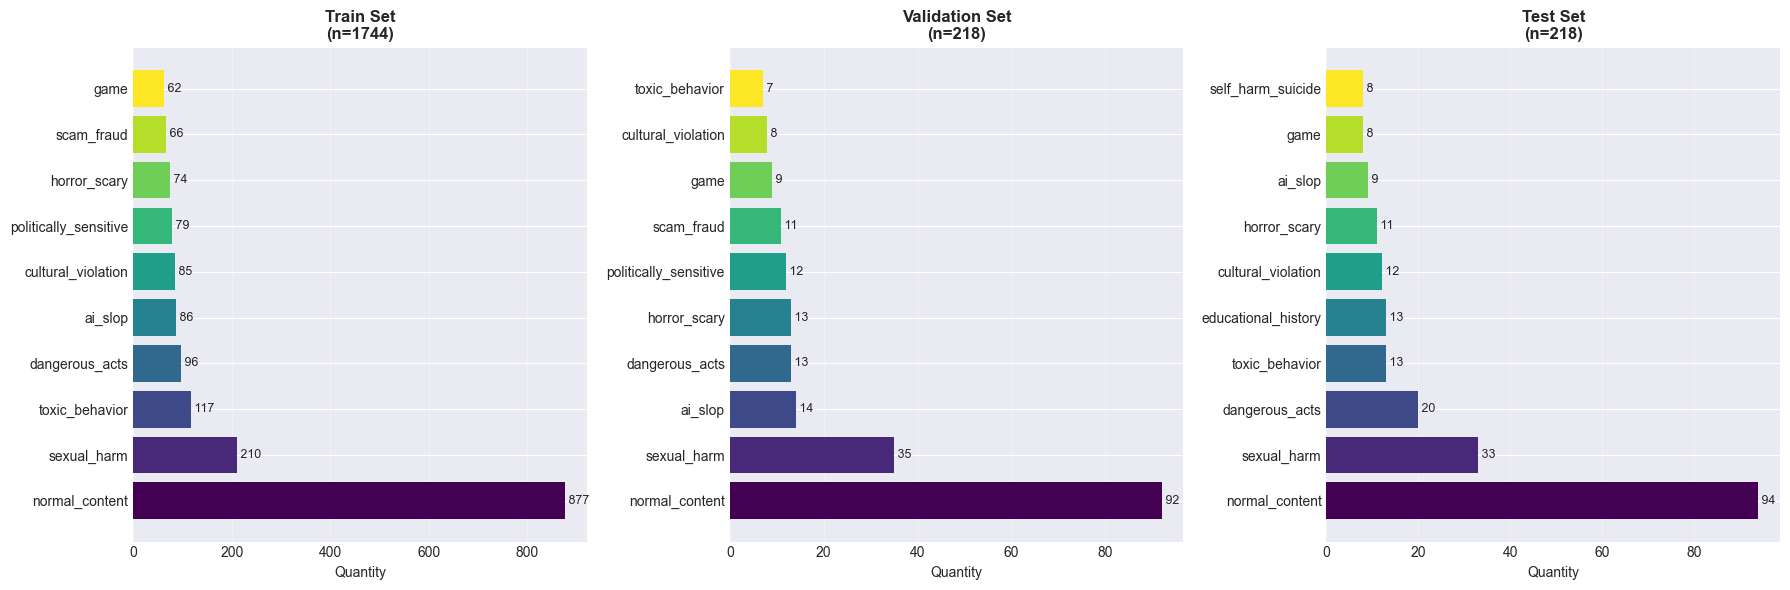

In [18]:
# Compare label distributions across train, val, test sets
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (dataset_name, df) in enumerate([('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    labels_list = []
    for label in df['label']:
        labels_list.extend(extract_labels(label))
    
    label_counts_subset = Counter(labels_list)
    labels_sorted = sorted(label_counts_subset.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = [l[0] for l in labels_sorted]
    counts = [l[1] for l in labels_sorted]
    
    axes[idx].barh(labels, counts, color=plt.cm.viridis(np.linspace(0, 1, len(labels))))
    axes[idx].set_xlabel('Quantity', fontsize=10)
    axes[idx].set_title(f'{dataset_name} Set\n(n={len(df)})', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    
    for i, count in enumerate(counts):
        axes[idx].text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

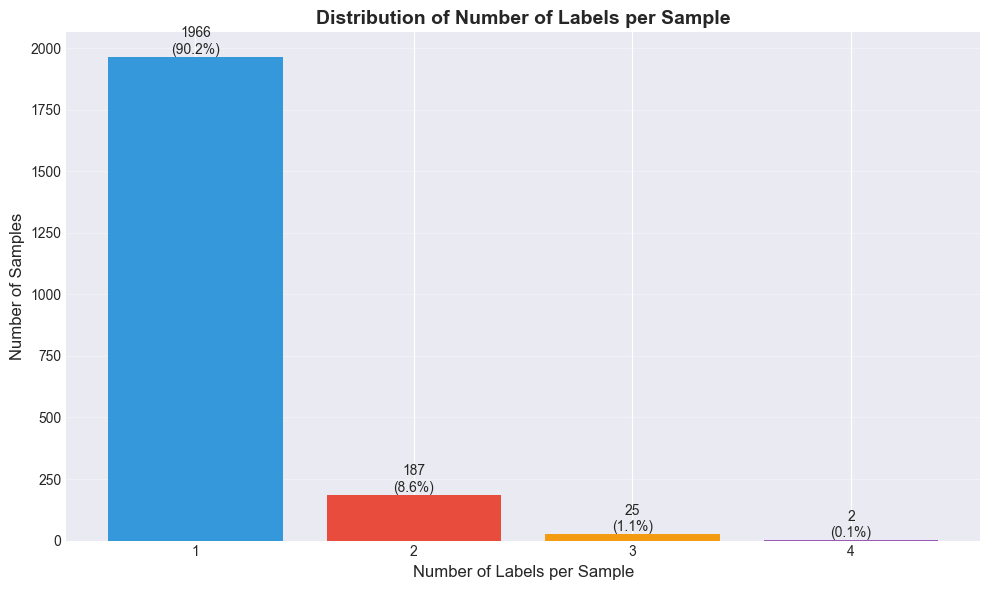


Statistics of Number of Labels per Sample:
count    2180.000000
mean        1.111468
std         0.357130
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: label, dtype: float64


In [20]:
# Distribution of number of labels per sample
labels_per_sample = all_data['label'].apply(lambda x: len(extract_labels(x)))

fig, ax = plt.subplots(figsize=(10, 6))
label_count_dist = labels_per_sample.value_counts().sort_index()
bars = ax.bar(label_count_dist.index, label_count_dist.values, 
              color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
ax.set_xlabel('Number of Labels per Sample', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Distribution of Number of Labels per Sample', fontsize=14, fontweight='bold')
ax.set_xticks(label_count_dist.index)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(all_data)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nStatistics of Number of Labels per Sample:")
print(labels_per_sample.describe())

# 6. Analyze multi-label

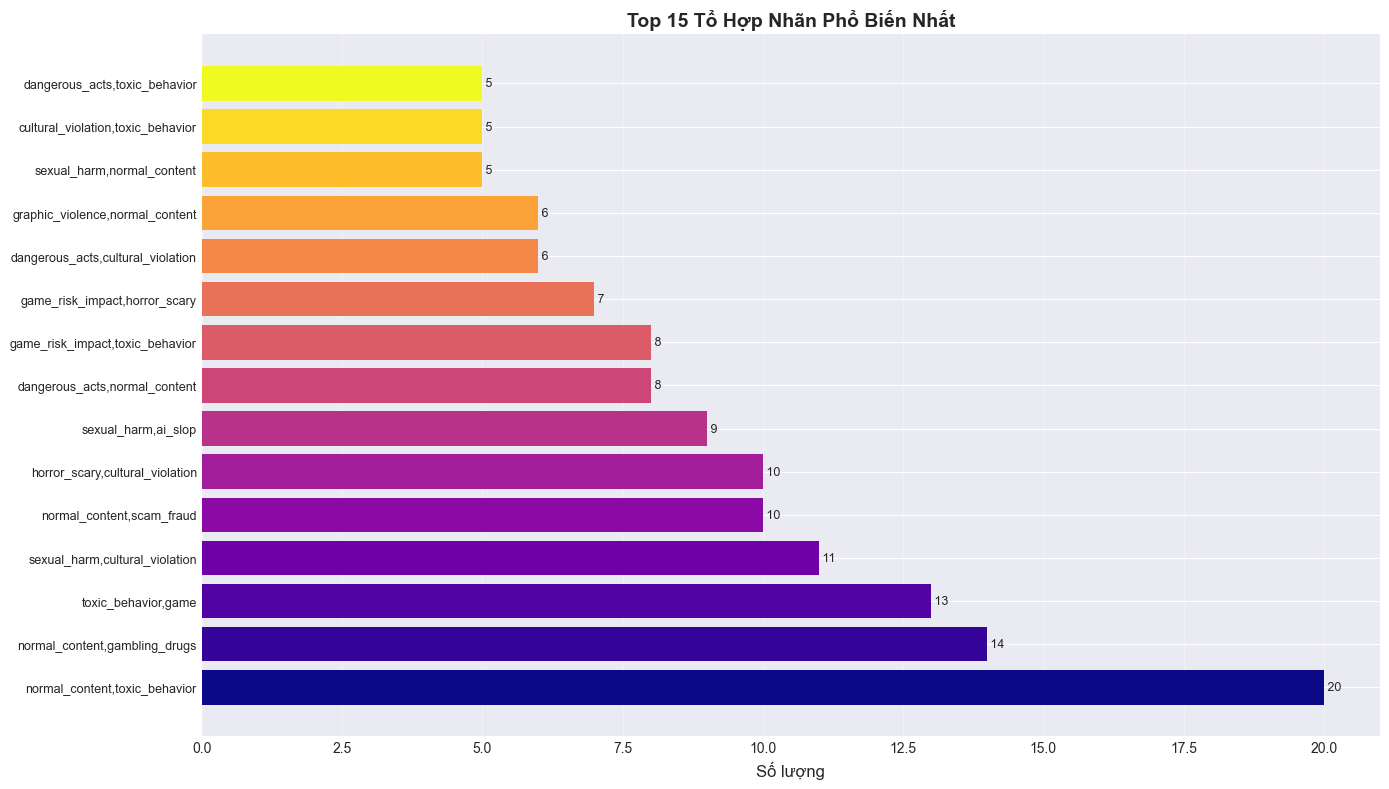

In [23]:
# Top các tổ hợp nhãn phổ biến nhất (cho multi-label)
multi_label_combos = multi_label_samples['label'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))
y_pos = np.arange(len(multi_label_combos))
bars = ax.barh(y_pos, multi_label_combos.values, color=plt.cm.plasma(np.linspace(0, 1, len(multi_label_combos))))
ax.set_yticks(y_pos)
ax.set_yticklabels([label[:50] + '...' if len(label) > 50 else label for label in multi_label_combos.index], fontsize=9)
ax.set_xlabel('Số lượng', fontsize=12)
ax.set_title('Top 15 Tổ Hợp Nhãn Phổ Biến Nhất', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, count in enumerate(multi_label_combos.values):
    ax.text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 7. Co-occurrence Matrix

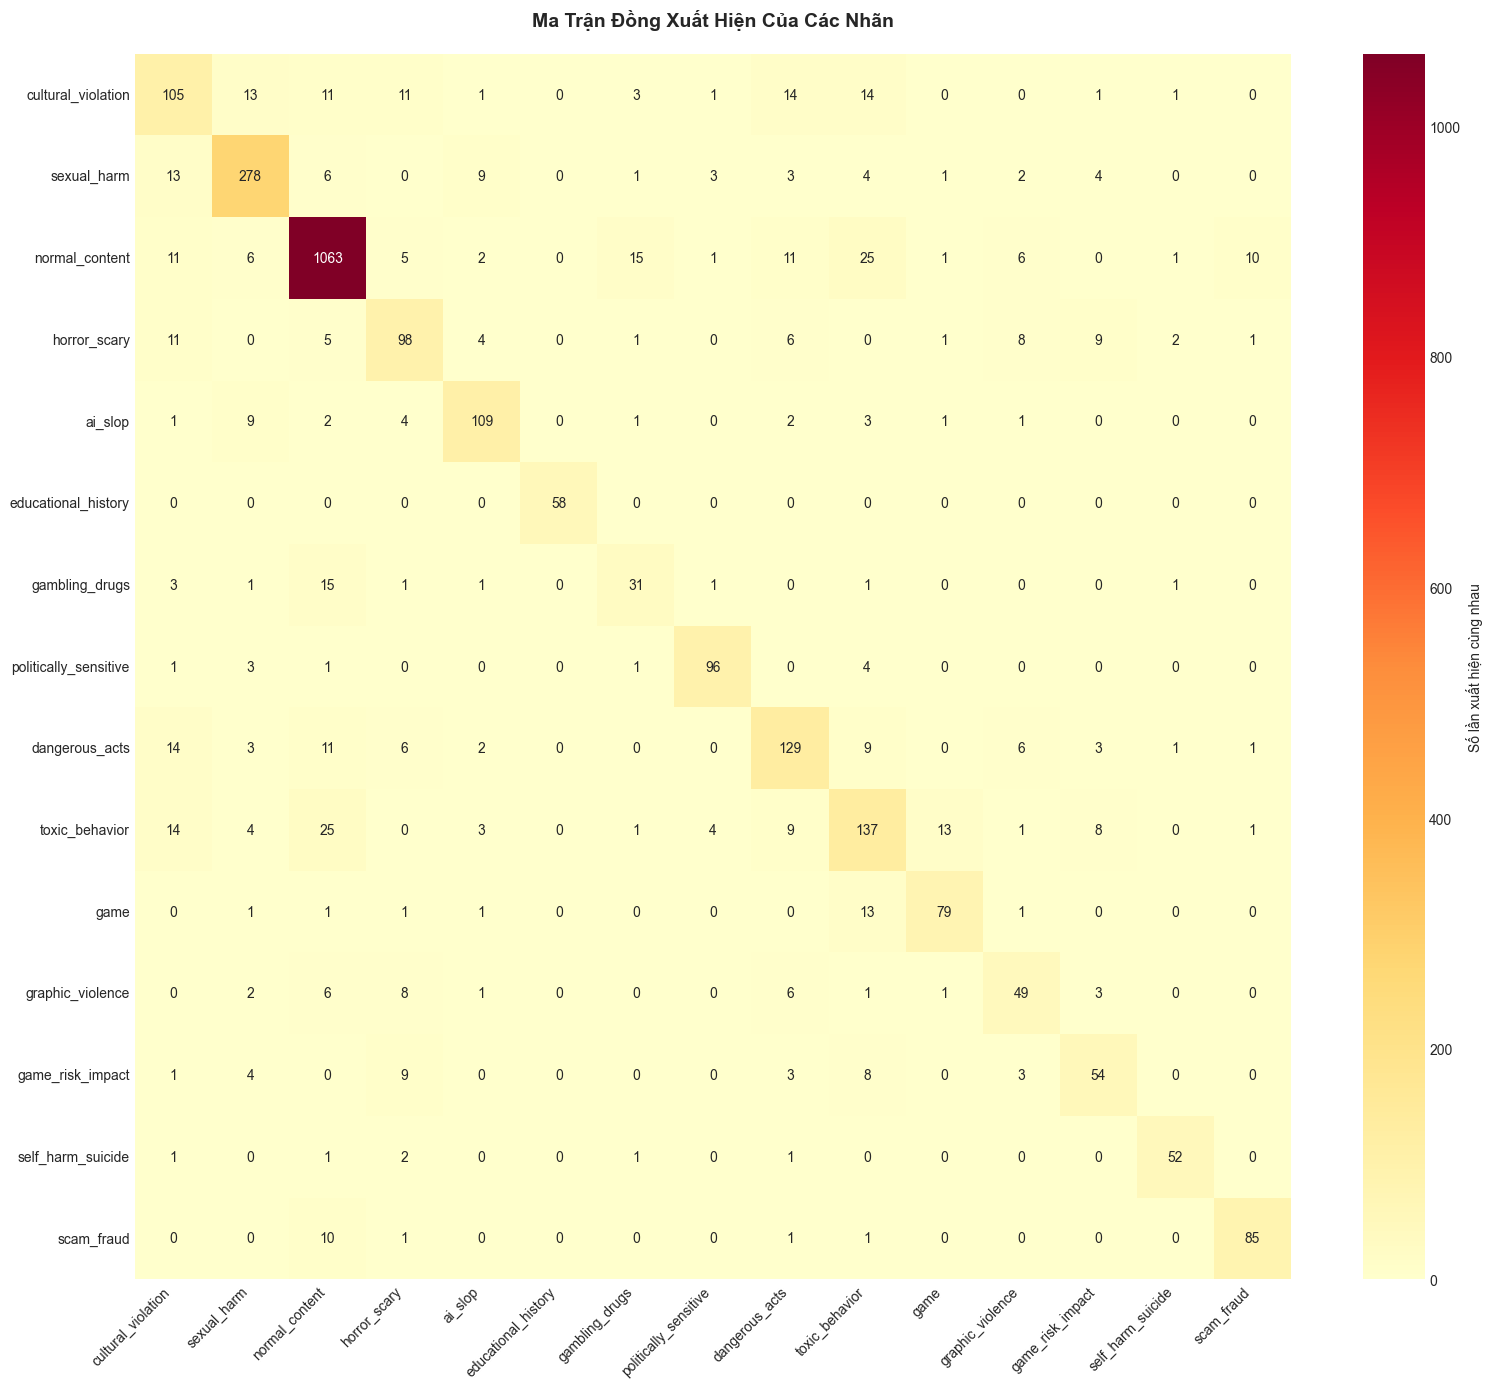

In [21]:
# Create co-occurrence matrix
unique_labels = list(label_counts.keys())
n_labels = len(unique_labels)
cooccurrence_matrix = np.zeros((n_labels, n_labels))

for label_str in all_data['label']:
    labels = extract_labels(label_str)
    for i, label1 in enumerate(unique_labels):
        for j, label2 in enumerate(unique_labels):
            if label1 in labels and label2 in labels:
                cooccurrence_matrix[i, j] += 1


fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cooccurrence_matrix, 
            xticklabels=unique_labels, 
            yticklabels=unique_labels,
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Số lần xuất hiện cùng nhau'},
            ax=ax)
ax.set_title('Ma Trận Đồng Xuất Hiện Của Các Nhãn', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()